<a href="https://colab.research.google.com/github/dughilamiruna/PMP-2026/blob/main/Lab02/tema1.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Exercitiul** **1**

In [ ]:
import pandas as pd
import numpy as np

def extragere(fisier_csv, k):
  df = pd.read_csv(fisier_csv)
  lista = df['Nume'].tolist()
  studenti_alesi = np.random.choice(lista, size=k, replace=False)
  return studenti_alesi

studenti = extragere('lista.csv', 7)
print(studenti)

['Marin Gabriel' 'Popescu Ion' 'Stoica Ana' 'Ionescu Maria'
 'Munteanu Vlad' 'Ilie Bogdan' 'Dumitrescu Elena']


**Exercitiul 2**

a) Distributia lui N?

Jocul consta intr-o succesiune de incercari si se opreste la primul succes. Deci N urmeaza o distributie geometrica.

b)

In [24]:
import numpy as np
import matplotlib.pyplot as plt

def simulare(p_stema=0.5):
  N = 0
  S = 0

  while True:
    N = N + 1
    moneda = np.random.choice([1, 0], p=[p_stema, 1 - p_stema])

    if moneda == 1:
      zar = np.random.choice([1, 2, 3, 4, 5, 6])
      S = S + (zar - 3)
      break

    else:
      S = S - 0.5

  return N, S

#Testare joc
rez_N, rez_S = simulare()
print(f"Jocul a durat N = {rez_N} pași, iar Jucătorul 2 trebuie să îi dea Jucătorului 1 suma de S = {rez_S} dolari.")

Jocul a durat N = 1 pași, iar Jucătorul 2 trebuie să îi dea Jucătorului 1 suma de S = -2 dolari.


c)

In [22]:
nr_simulari = 10000
sume = []

for _ in range(nr_simulari):
  suma_obtinuta = simulare(p_stema=0.5)[1]
  sume.append(suma_obtinuta)

media_S = np.mean(sume)
print(f"Pentru o monedă normală, media estimată a sumei S din {nr_simulari} jocuri este: {media_S:.4f}")

Pentru o monedă normală, media estimată a sumei S din 10000 jocuri este: -0.0011


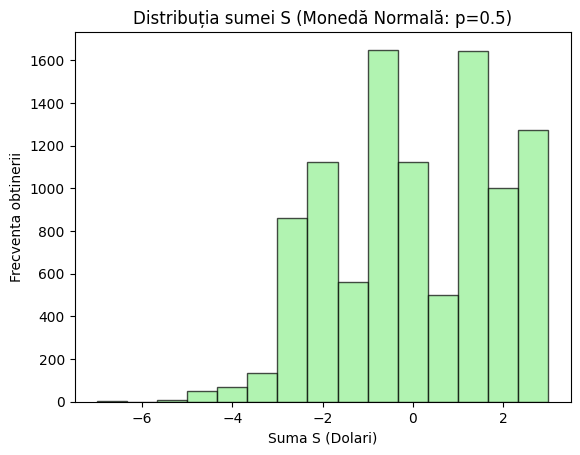

In [25]:
#Histograma
plt.hist(sume, bins=15, alpha=0.7, color='lightgreen', edgecolor='black')
plt.title('Distribuția sumei S (Monedă Normală: p=0.5)')
plt.xlabel('Suma S (Dolari)')
plt.ylabel('Frecventa obtinerii')
plt.show()

d)

Pentru o monedă cu p=0.3, media estimată a sumei S este: -0.6663
Pentru o monedă cu p=0.7, media estimată a sumei S este: 0.2681


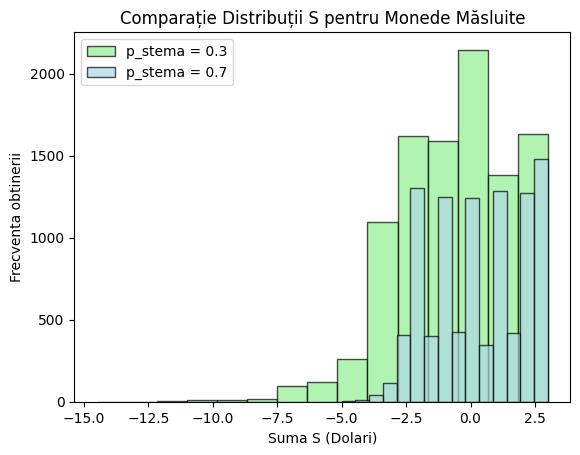

In [29]:
nr_simulari = 10000
sume1 = []
sume2 = []

for _ in range(nr_simulari):
  suma_obtinuta = simulare(p_stema=0.3)[1]
  sume1.append(suma_obtinuta)

for _ in range(nr_simulari):
  suma_obtinuta = simulare(p_stema=0.7)[1]
  sume2.append(suma_obtinuta)

media_sume1 = np.mean(sume1)
print(f"Pentru o monedă cu p=0.3, media estimată a sumei S este: {media_sume1:.4f}")
media_sume2 = np.mean(sume2)
print(f"Pentru o monedă cu p=0.7, media estimată a sumei S este: {media_sume2:.4f}")

plt.hist(sume1, bins=15, alpha=0.7, color='lightgreen', edgecolor='black', label='p_stema = 0.3')
plt.hist(sume2, bins=15, alpha=0.7, color='lightblue', edgecolor='black', label='p_stema = 0.7')
plt.title('Comparație Distribuții S pentru Monede Măsluite')
plt.xlabel('Suma S (Dolari)')
plt.ylabel('Frecventa obtinerii')
plt.legend()
plt.show()

**Exercitiul 3**

In [36]:
import numpy as np
import matplotlib.pyplot as plt
import arviz as az

nr_clienti = 10000
prob = [3/13, 6/13, 4/13]
l = [3, 6, 4]
timp_X = []

for _ in range(nr_clienti):
  frizer = np.random.choice([0, 1, 2], p=prob)
  timp = np.random.exponential(scale=1/l[frizer])
  timp_X.append(timp)

X = np.array(timp_X)
media_X = np.mean(X)
deviatia_X = np.std(X)

print(f"Media estimată pentru timpul de servire X: {media_X:.4f} ore")
print(f"Deviația standard estimată pentru X: {deviatia_X:.4f} ore")

Media estimată pentru timpul de servire X: 0.2285 ore
Deviația standard estimată pentru X: 0.2396 ore


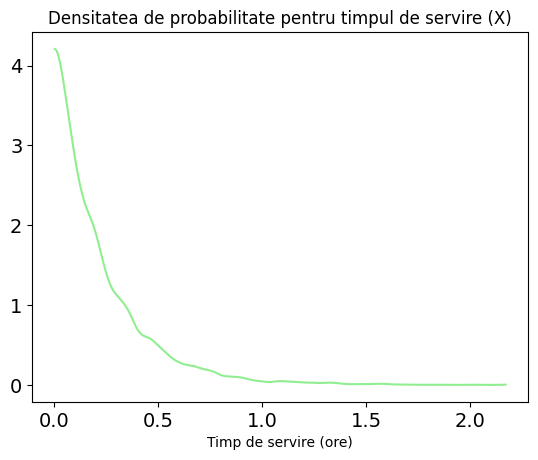

In [40]:
az.plot_kde(X, plot_kwargs={'color': 'lightgreen'})
plt.title('Densitatea de probabilitate pentru timpul de servire (X)')
plt.xlabel('Timp de servire (ore)')
plt.show()